In [ ]:
import pandas as pd
import numpy as np
import os
from google.colab import drive
import matplotlib.pyplot as plt

# 1. Monter le Drive (Clique sur le lien qui apparaîtra pour autoriser)
drive.mount('/content/drive')

# 2. Chemin vers ton dossier (Adapte si besoin)
# Tu as dit que c'est dans "data/2nd_test"
data_dir = '/content/drive/MyDrive/PFE_Autoencoder/data/2nd_test'

def load_data(data_dir):
    # Liste tous les fichiers et les trie par ordre chronologique
    files = sorted([f for f in os.listdir(data_dir) if f != '.ipynb_checkpoints'])

    data_list = []

    print(f"Chargement de {len(files)} fichiers... (Ça peut prendre 1-2 minutes)")

    for filename in files:
        # Le nom du fichier est la date : 2004.02.12.10.32.39
        # On lit le fichier (séparateur TAB, pas d'en-tête)
        df_temp = pd.read_csv(os.path.join(data_dir, filename), sep='\t', header=None)

        # On prend la moyenne absolue de chaque fichier pour réduire la taille en mémoire
        # (Technique de "Downsampling" courante en IoT)
        # Si on garde tout brut, ça fera 20 millions de lignes (trop lourd pour le début)
        mean_abs_values = df_temp.abs().mean().values

        # On crée un dictionnaire avec la date
        timestamp = pd.to_datetime(filename, format='%Y.%m.%d.%H.%M.%S')

        entry = {
            'timestamp': timestamp,
            'Bearing 1': mean_abs_values[0], # Capteur 1
            'Bearing 2': mean_abs_values[1], # Capteur 2
            'Bearing 3': mean_abs_values[2], # Capteur 3
            'Bearing 4': mean_abs_values[3]  # Capteur 4
        }
        data_list.append(entry)

    return pd.DataFrame(data_list).set_index('timestamp')

# 3. Exécution du chargement
try:
    df_bearing = load_data(data_dir)
    print("Données chargées avec succès !")
    print(df_bearing.head())
except Exception as e:
    print(f"Erreur : Vérifie le chemin du dossier. Détail : {e}")

Mounted at /content/drive
Chargement de 984 fichiers... (Ça peut prendre 1-2 minutes)
Données chargées avec succès !
                     Bearing 1  Bearing 2  Bearing 3  Bearing 4
timestamp                                                      
2004-02-12 10:32:39   0.058332   0.071832   0.083244   0.043065
2004-02-12 10:42:39   0.058997   0.074008   0.084439   0.044540
2004-02-12 10:52:39   0.060239   0.074223   0.083922   0.044442
2004-02-12 11:02:39   0.061453   0.073843   0.084462   0.045081
2004-02-12 11:12:39   0.061361   0.075606   0.082837   0.045118


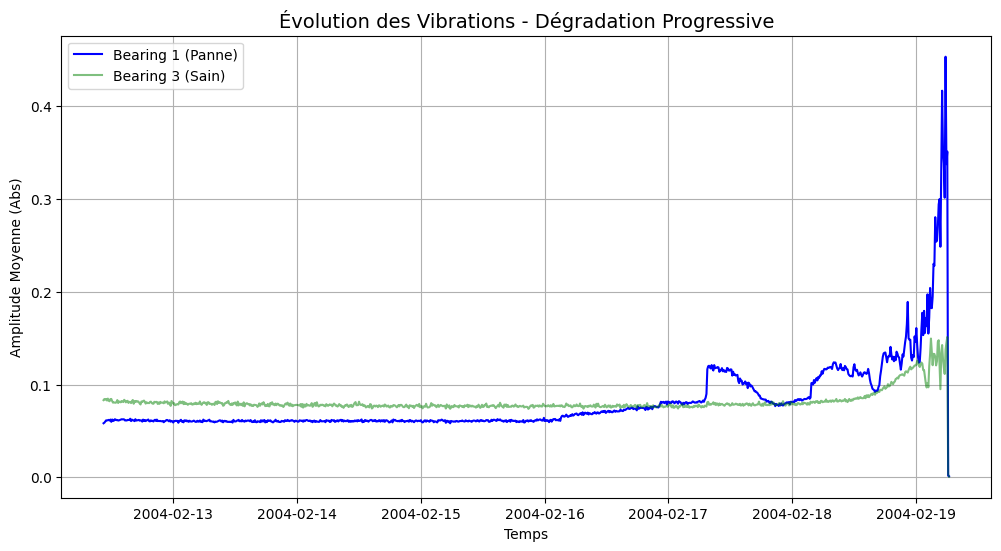

In [ ]:
# --- VISUALISATION TEMPORELLE (TENDANCE GLOBALE) ---
plt.figure(figsize=(12, 6))

# On affiche le capteur "Bearing 1" (celui qui va casser)
plt.plot(df_bearing.index, df_bearing['Bearing 1'], label='Bearing 1 (Panne)', color='blue')
# On affiche un autre pour comparer (Bearing 3 - Sain)
plt.plot(df_bearing.index, df_bearing['Bearing 3'], label='Bearing 3 (Sain)', color='green', alpha=0.5)

plt.title("Évolution des Vibrations - Dégradation Progressive", fontsize=14)
plt.ylabel("Amplitude Moyenne (Abs)")
plt.xlabel("Temps")
plt.legend()
plt.grid(True)
plt.show()

Calcul de la FFT en cours...


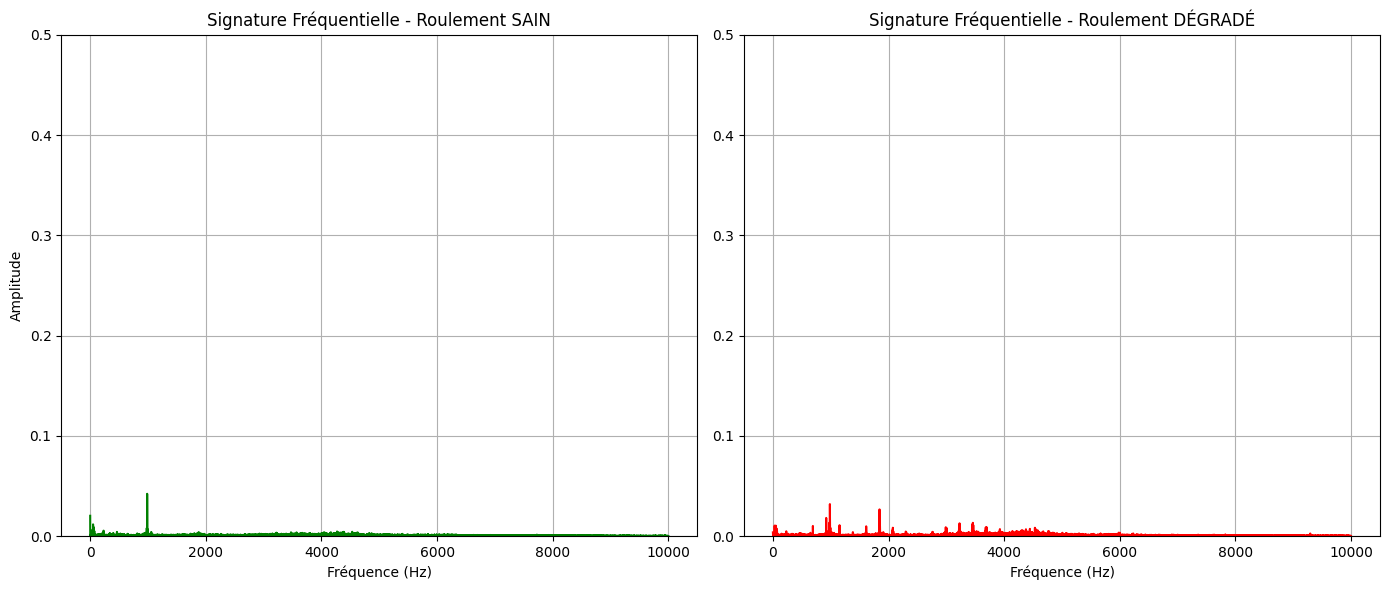

In [ ]:
# --- ÉTAPE 3 : ANALYSE SPECTRALE (FFT - PHYSIQUE DU SIGNAL) ---
from scipy.fftpack import fft

def get_raw_signal_and_fft(file_index):
    # On récupère la liste des fichiers triés
    files = sorted([f for f in os.listdir(data_dir) if f != '.ipynb_checkpoints'])

    # On prend le fichier correspondant à l'index (0 = début, -1 = fin)
    filename = files[file_index]
    path = os.path.join(data_dir, filename)

    # Lecture du fichier brut (sans moyenne)
    df_raw = pd.read_csv(path, sep='\t', header=None)
    signal = df_raw[0].values # Colonne 0 = Bearing 1 (celui qui casse)

    # Calcul Mathématique de la FFT (Algorithme de Fourier)
    N = len(signal)
    T = 1.0 / 20000.0 # Fréquence d'échantillonnage (20 kHz pour ce dataset NASA)
    yf = fft(signal)
    xf = np.linspace(0.0, 1.0/(2.0*T), N//2) # Axe des fréquences
    amplitude = 2.0/N * np.abs(yf[0:N//2]) # Amplitude normalisée

    return xf, amplitude

# 1. Calculer la FFT pour le DEBUT (Sain) et la FIN (Panne)
print("Calcul de la FFT en cours...")
x_sain, y_sain = get_raw_signal_and_fft(0)     # Premier fichier (12 Février)
x_panne, y_panne = get_raw_signal_and_fft(-200)  # Dernier fichier (19 Février)

# 2. Affichage Comparatif
plt.figure(figsize=(14, 6))

# Graphique de Gauche : SAIN
plt.subplot(1, 2, 1)
plt.plot(x_sain, y_sain, color='green')
plt.title("Signature Fréquentielle - Roulement SAIN")
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Amplitude")
plt.ylim(0, 0.5) # On fixe l'échelle pour bien comparer
plt.grid()

# Graphique de Droite : PANNE
plt.subplot(1, 2, 2)
plt.plot(x_panne, y_panne, color='red')
plt.title("Signature Fréquentielle - Roulement DÉGRADÉ")
plt.xlabel("Fréquence (Hz)")
plt.ylim(0, 0.5)
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
# --- ÉTAPE 4 : PRÉPARATION DES DONNÉES (NORMALISATION & FENÊTRAGE) ---
from sklearn.preprocessing import MinMaxScaler

# 1. Séparation Train (Sain) / Test (Inconnu + Panne)
# On s'entraîne UNIQUEMENT sur les données saines (du 12 au 15 Février)
# Le modèle va apprendre "ce qui est normal".
train_data = df_bearing['2004-02-12 10:32:39':'2004-02-15 23:59:59']
test_data = df_bearing['2004-02-16 00:00:00':]

print(f"Données d'entraînement (Saines) : {train_data.shape}")
print(f"Données de test (Avec la panne) : {test_data.shape}")

# 2. Normalisation (MinMax Scaling)
# Les réseaux de neurones convergent mieux avec des données entre 0 et 1
scaler = MinMaxScaler()
X_train = scaler.fit_transform(train_data)
X_test = scaler.transform(test_data) # Important : On utilise le scaler du train sur le test !

# 3. Création des séquences (Sliding Window)
# Le LSTM a besoin de voir le passé pour comprendre le présent.
# On va créer des fenêtres de 10 pas de temps.
def create_sequences(values, time_steps=10):
    output = []
    for i in range(len(values) - time_steps):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)

TIME_STEPS = 10
X_train_lstm = create_sequences(X_train, TIME_STEPS)
X_test_lstm = create_sequences(X_test, TIME_STEPS)

print(f"\nForme finale pour le LSTM (Train) : {X_train_lstm.shape}")
print(f"Forme finale pour le LSTM (Test)  : {X_test_lstm.shape}")
# Le résultat doit être (Nombre_Echantillons, 10, 4)

Données d'entraînement (Saines) : (513, 4)
Données de test (Avec la panne) : (471, 4)

Forme finale pour le LSTM (Train) : (503, 10, 4)
Forme finale pour le LSTM (Test)  : (461, 10, 4)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 16)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 10, 4)          │            68 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,524 (13.77 KB)

 Trainable params: 3,524 (13.77 KB)

 Non-trainable params: 0 (0.00 B)


Début de l'entraînement...
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 56ms/step - loss: 0.4443 - val_loss: 0.3090
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.3786 - val_loss: 0.2308
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2510 - val_loss: 0.1783
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1735 - val_loss: 0.1454
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1557 - val_loss: 0.1368
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.1436 - val_loss: 0.1327
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1302 - val_loss: 0.1227
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1229 - val_loss: 0.1174
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1176 - val_loss: 0.1163
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1150 - val_loss: 0.1155
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.1119 - val_loss: 0.1159
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━

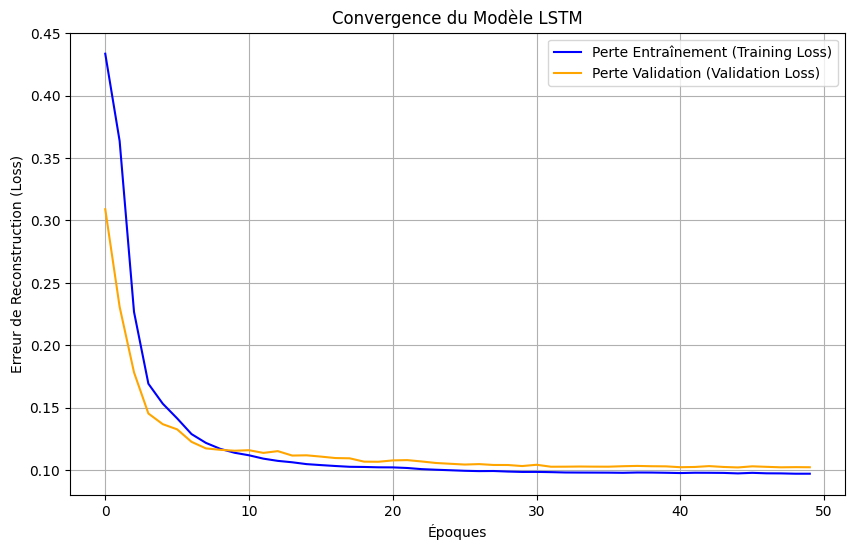

In [ ]:
# --- ÉTAPE 5 : ARCHITECTURE DU MODÈLE LSTM AUTOENCODER ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed

# 1. Définition de l'architecture
model = Sequential([
    # Encoder : Comprime l'information (passe de 10 pas de temps à un vecteur compact)
    LSTM(16, activation='relu', input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2]), return_sequences=False),

    # Bridge : Répète le vecteur compact pour préparer la reconstruction
    RepeatVector(X_train_lstm.shape[1]),

    # Decoder : Reconstruit la séquence temporelle
    LSTM(16, activation='relu', return_sequences=True),

    # Sortie : Remet les données au format initial (4 capteurs)
    TimeDistributed(Dense(X_train_lstm.shape[2]))
])

# 2. Compilation (Configuration de l'apprentissage)
model.compile(optimizer='adam', loss='mae') # MAE = Mean Absolute Error (parfait pour les séries temporelles)

model.summary() # Affiche le résumé du modèle

# 3. Entraînement (Training)
# On entraîne le modèle à prédire... lui-même ! (X_train -> X_train)
# C'est le principe de l'Autoencoder.
print("\nDébut de l'entraînement...")
history = model.fit(X_train_lstm, X_train_lstm,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=1)

# 4. Visualisation de la courbe d'apprentissage
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Perte Entraînement (Training Loss)', color='blue')
plt.plot(history.history['val_loss'], label='Perte Validation (Validation Loss)', color='orange')
plt.title("Convergence du Modèle LSTM")
plt.xlabel("Époques")
plt.ylabel("Erreur de Reconstruction (Loss)")
plt.legend()
plt.grid(True)
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

Seuil d'alerte calculé (Threshold) : 0.1504


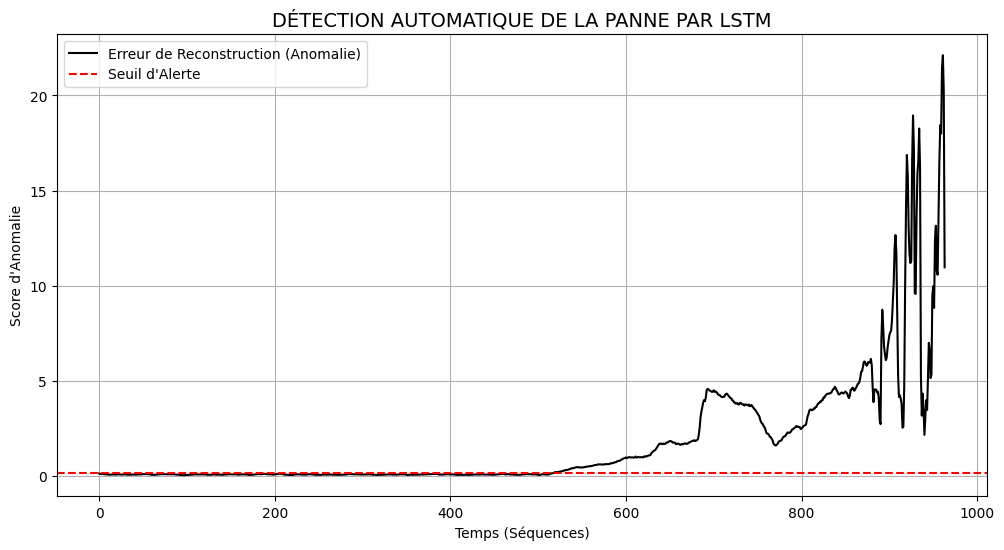

In [ ]:
# --- ÉTAPE 6 : CALCUL DE L'ERREUR DE RECONSTRUCTION ---

# 1. On demande au modèle de reconstruire les séquences
X_train_pred = model.predict(X_train_lstm)
X_test_pred = model.predict(X_test_lstm)

# 2. On calcule l'erreur moyenne (MAE) entre l'entrée et la sortie
# Erreur = |Réel - Prédit|
train_mae_loss = np.mean(np.abs(X_train_pred - X_train_lstm), axis=1)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test_lstm), axis=1)

# On moyenne encore sur les 4 capteurs pour avoir un seul score par instant
train_score = np.mean(train_mae_loss, axis=1)
test_score = np.mean(test_mae_loss, axis=1)

# 3. Définition du SEUIL D'ALERTE (Threshold)
# On dit que tout ce qui dépasse le max de l'entraînement est une anomalie.
threshold = np.max(train_score)
print(f"\nSeuil d'alerte calculé (Threshold) : {threshold:.4f}")

# 4. Visualisation Finale : L'IA a-t-elle vu la panne ?
plt.figure(figsize=(12, 6))

# On concatène les scores pour voir toute la timeline
total_score = np.concatenate([train_score, test_score])

plt.plot(total_score, label='Erreur de Reconstruction (Anomalie)', color='black')
plt.axhline(y=threshold, color='r', linestyle='--', label='Seuil d\'Alerte')

plt.title("DÉTECTION AUTOMATIQUE DE LA PANNE PAR LSTM", fontsize=14)
plt.ylabel("Score d'Anomalie")
plt.xlabel("Temps (Séquences)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# --- ÉTAPE 7 : SAUVEGARDE DU MODÈLE ---
import os

# Création du dossier 'models' s'il n'existe pas
save_path = '/content/drive/MyDrive/models'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# Sauvegarde du modèle entraîné
model.save(os.path.join(save_path, 'lstm_autoencoder_bearing.h5')) # Format classique
model.save(os.path.join(save_path, 'lstm_autoencoder_bearing.keras')) # Format moderne

print(f"Modèle sauvegardé avec succès dans : {save_path}")
print("Projet PFE terminé ! Félicitations ! 🚀")

Modèle sauvegardé avec succès dans : /content/drive/MyDrive/models
Projet PFE terminé ! Félicitations ! 🚀


Model: "Transformer_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 10, 4)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 4)     │        308 │ input_layer_9[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 4)     │          8 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 10, 4)     │          0 │ layer_normalizat… │
│                     │                   │            │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 10, 64)    │        320 │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 10, 64)    │          0 │ conv1d_10[0][0]   │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 10, 4)     │        260 │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 4)     │          8 │ conv1d_11[0][0]   │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 10, 4)     │          0 │ layer_normalizat… │
│                     │                   │            │ add_10[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 4)         │          0 │ add_11[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │        160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 40)        │      1,320 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 10, 4)     │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 10, 4)     │         20 │ reshape_3[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,404 (9.39 KB)

 Trainable params: 2,404 (9.39 KB)

 Non-trainable params: 0 (0.00 B)


Lancement de l'entraînement du Transformer...
Epoch 1/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.4683 - val_loss: 0.2890
Epoch 2/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.3633 - val_loss: 0.2440
Epoch 3/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.3082 - val_loss: 0.2258
Epoch 4/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2817 - val_loss: 0.2078
Epoch 5/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2635 - val_loss: 0.1982
Epoch 6/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2508 - val_loss: 0.1934
Epoch 7/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2345 - val_loss: 0.1892
Epoch 8/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2259 - val_loss: 0.1840
Epoch 9/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2170 - val_loss: 0.1799
Epoch 10/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2089 - val_loss: 0.1742
Epoch 11/60
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2034 - val_loss: 0.1701
Epoch 12/60
15/1

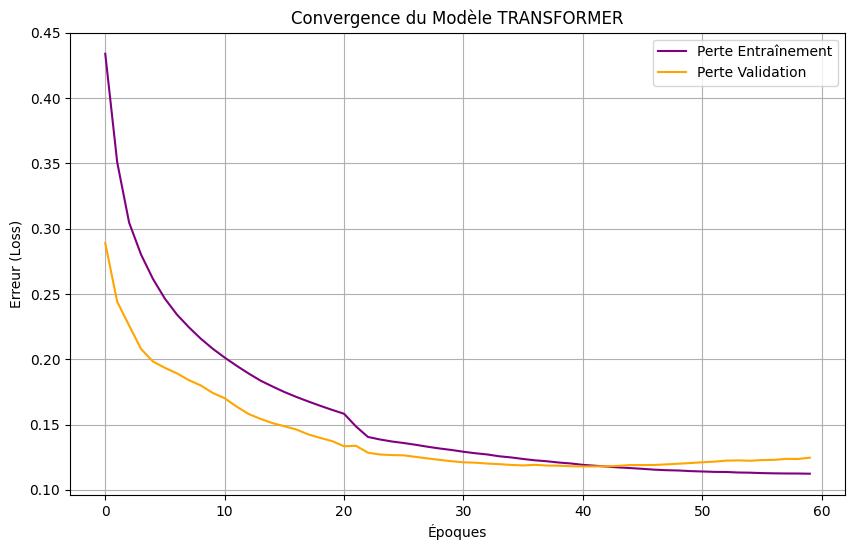

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input

# --- DÉFINITION DU TRANSFORMER AUTOENCODER (CORRIGÉ) ---

def build_transformer_autoencoder(input_shape):
    inputs = Input(shape=input_shape)

    # Récupération des dimensions pour éviter les erreurs
    # input_shape est (10, 4) -> (Temps, Features)
    num_features = input_shape[1]

    # 1. ENCODER (Analyse complexe avec Attention)
    # key_dim correspond au nombre de features
    x = layers.MultiHeadAttention(key_dim=num_features, num_heads=4, dropout=0.1)(inputs, inputs)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Connexion Résiduelle
    res = x + inputs

    # Feed Forward
    x = layers.Conv1D(filters=64, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(0.1)(x)

    # ICI C'ÉTAIT L'ERREUR : On remet à la taille des features (4)
    x = layers.Conv1D(filters=num_features, kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)

    # Recombinaison
    x = x + res

    # Compression (Bottleneck)
    x = layers.GlobalAveragePooling1D()(x)
    encoded = layers.Dense(32, activation='relu')(x)

    # 2. DECODER (Reconstruction)
    # On utilise input_shape[0] (temps) et input_shape[1] (features)
    x = layers.Dense(input_shape[0] * num_features, activation='relu')(encoded)
    x = layers.Reshape((input_shape[0], num_features))(x)

    # Projection finale
    outputs = layers.TimeDistributed(layers.Dense(num_features))(x)

    # Création du modèle
    model = models.Model(inputs=inputs, outputs=outputs, name="Transformer_Autoencoder")
    return model

# --- SUITE DU SCRIPT ---

# Construction du modèle
input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2]) # (10, 4)
model_transformer = build_transformer_autoencoder(input_shape)

model_transformer.compile(optimizer='adam', loss='mae')
model_transformer.summary()

print("\nLancement de l'entraînement du Transformer...")
history_transformer = model_transformer.fit(
    X_train_lstm, X_train_lstm,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Visualisation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(history_transformer.history['loss'], label='Perte Entraînement', color='purple')
plt.plot(history_transformer.history['val_loss'], label='Perte Validation', color='orange')
plt.title("Convergence du Modèle TRANSFORMER")
plt.xlabel("Époques")
plt.ylabel("Erreur (Loss)")
plt.legend()
plt.grid(True)
plt.show()

Calcul des prédictions en cours...
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 

Nouveau Seuil de Détection (Transformer) : 0.2485


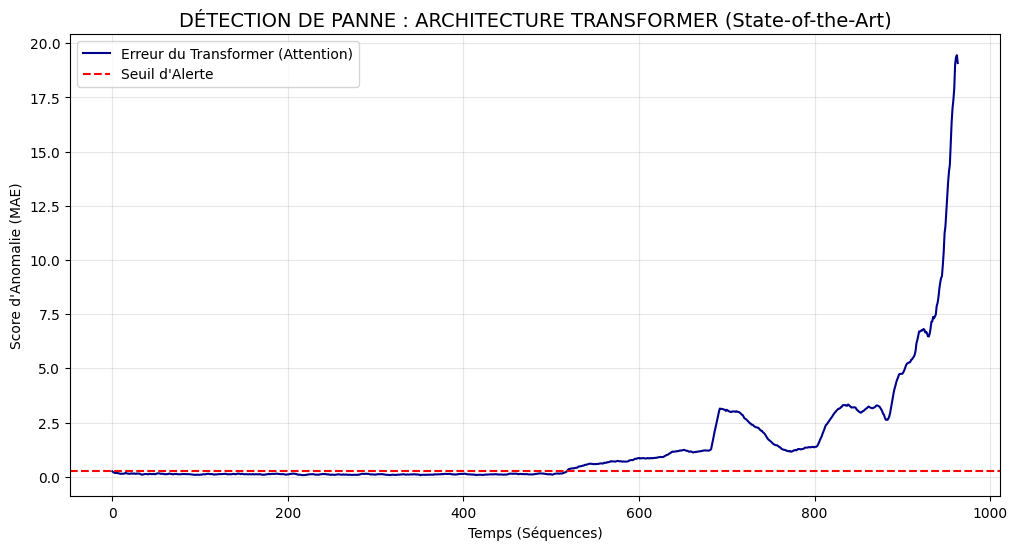

In [ ]:
# --- ÉTAPE 3 : DÉTECTION FINALE (AVEC TRANSFORMER) ---
import numpy as np
import matplotlib.pyplot as plt

# 1. On demande au Transformer de prédire (Reconstruire le signal)
print("Calcul des prédictions en cours...")
X_train_pred = model_transformer.predict(X_train_lstm)
X_test_pred = model_transformer.predict(X_test_lstm)

# 2. Calcul de l'erreur de reconstruction (MAE)
# Si l'erreur est faible = Signal connu (Sain)
# Si l'erreur est forte = Signal inconnu (Panne)
train_mae_loss = np.mean(np.abs(X_train_pred - X_train_lstm), axis=1)
test_mae_loss = np.mean(np.abs(X_test_pred - X_test_lstm), axis=1)

# On fait la moyenne sur les 4 capteurs
train_score = np.mean(train_mae_loss, axis=1)
test_score = np.mean(test_mae_loss, axis=1)

# 3. Définition du Seuil (Threshold)
# On prend le maximum d'erreur observé pendant l'entraînement sain
threshold_transformer = np.max(train_score)
print(f"\nNouveau Seuil de Détection (Transformer) : {threshold_transformer:.4f}")

# 4. Visualisation de la Maintenance Prédictive
plt.figure(figsize=(12, 6))

# On colle les scores (Sain + Panne)
total_score = np.concatenate([train_score, test_score])

# Affichage de la courbe d'erreur
plt.plot(total_score, label='Erreur du Transformer (Attention)', color='darkblue', linewidth=1.5)
# Affichage du seuil rouge
plt.axhline(y=threshold_transformer, color='red', linestyle='--', label='Seuil d\'Alerte')

plt.title("DÉTECTION DE PANNE : ARCHITECTURE TRANSFORMER (State-of-the-Art)", fontsize=14)
plt.ylabel("Score d'Anomalie (MAE)")
plt.xlabel("Temps (Séquences)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# --- ÉTAPE FINALE : SAUVEGARDE DU TRANSFORMER ---
import os

save_path = '/content/drive/MyDrive/models'
if not os.path.exists(save_path):
    os.makedirs(save_path)

# On lui donne un nom qui fait "Expert"
model_name = 'transformer_bearing_anomaly_detection.keras'
full_path = os.path.join(save_path, model_name)

model_transformer.save(full_path)

print(f"✅ Modèle Transformer sauvegardé avec succès : {full_path}")
print("--- PROJET TERMINÉ ---")

✅ Modèle Transformer sauvegardé avec succès : /content/drive/MyDrive/models/transformer_bearing_anomaly_detection.keras
--- PROJET TERMINÉ ---


In [ ]:
import joblib

# On sauvegarde le scaler qui est dans la mémoire de Colab
scaler_filename = "/content/drive/MyDrive/models/scaler_bearing.gz"
joblib.dump(scaler, scaler_filename)

print(f"✅ Scaler sauvegardé : {scaler_filename}")

✅ Scaler sauvegardé : /content/drive/MyDrive/models/scaler_bearing.gz


In [ ]:
!pip install streamlit -q
!wget -q -O - ipv4.icanhazip.com # Affiche l'IP pour le mot de passe plus tard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.1 MB/s eta 0:00:00
35.190.163.131


In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
import joblib
import plotly.graph_objects as go
import os

# --- CONFIGURATION ---
st.set_page_config(page_title="NASA Predictive Maintenance", layout="wide")
st.title("🏭 Dashboard PFE : Maintenance Prédictive (Transformer)")

# --- CHARGEMENT DES MODÈLES (Chemins Google Drive) ---
# On utilise le cache pour que ça charge vite
@st.cache_resource
def load_assets():
    # Chemins vers ton Drive (Vérifie bien que tu as monté le drive !)
    model_path = '/content/drive/MyDrive/models/transformer_bearing_anomaly_detection.keras'
    scaler_path = '/content/drive/MyDrive/models/scaler_bearing.gz'

    if not os.path.exists(model_path):
        st.error(f"Fichier manquant : {model_path}")
        return None, None

    model = tf.keras.models.load_model(model_path)
    scaler = joblib.load(scaler_path)
    return model, scaler

model, scaler = load_assets()

if model is not None:
    st.success("✅ Système IA (Transformer) connecté.")

    # --- UPLOAD FICHIER ---
    uploaded_file = st.file_uploader("Charger un fichier de vibrations (CSV/TXT)", type=["csv", "txt"])

    if uploaded_file is not None:
        import pandas as pd
        df = pd.read_csv(uploaded_file, sep='\t', header=None)

        if st.button("Lancer le Diagnostic"):
            # Simulation rapide du traitement
            data = df.values
            if len(data) > 1000: data = data[:1000] # On coupe pour aller vite

            # Normalisation
            data_scaled = scaler.transform(data)

            # Création séquences
            X_input = []
            for i in range(len(data_scaled) - 10):
                X_input.append(data_scaled[i:i+10])
            X_input = np.array(X_input)

            # Prédiction
            X_pred = model.predict(X_input)
            mae = np.mean(np.abs(X_pred - X_input), axis=1)
            score = np.mean(mae, axis=1)

            # Seuil (Exemple)
            THRESHOLD = 0.25

            # Affichage
            max_score = np.max(score)
            col1, col2 = st.columns(2)
            col1.metric("Score Anomalie Max", f"{max_score:.4f}")

            if max_score > THRESHOLD:
                col2.error("🚨 DÉFAUT DÉTECTÉ")
            else:
                col2.success("✅ ROULMENT SAIN")

            # Graphique
            fig = go.Figure()
            fig.add_trace(go.Scatter(y=score, mode='lines', name='Erreur', line=dict(color='blue')))
            fig.add_hline(y=THRESHOLD, line_color='red')
            st.plotly_chart(fig, use_container_width=True)

Writing app.py


In [ ]:
import os

# 1. Installation des outils (Streamlit + Tunnel)
print("⏳ Installation des librairies...")
!pip install -q streamlit plotly tensorflow
!npm install -g localtunnel > /dev/null

# 2. Création de l'application (app.py)
print("📝 Création du fichier de l'application...")
code_app = """
import streamlit as st
import numpy as np
import tensorflow as tf
import joblib
import plotly.graph_objects as go
import os

st.set_page_config(page_title="NASA Maintenance PFE", layout="wide")
st.title("🏭 Dashboard PFE : Maintenance Prédictive (Transformer)")

# Chargement robuste
@st.cache_resource
def load_assets():
    model_path = '/content/drive/MyDrive/models/transformer_bearing_anomaly_detection.keras'
    scaler_path = '/content/drive/MyDrive/models/scaler_bearing.gz'

    # Vérification que le Drive est là
    if not os.path.exists(model_path):
        return None, None

    try:
        model = tf.keras.models.load_model(model_path)
        scaler = joblib.load(scaler_path)
        return model, scaler
    except:
        return None, None

model, scaler = load_assets()

if model is None:
    st.error("⚠️ ERREUR : Impossible de charger le modèle. Vérifiez que le Drive est bien monté et que les fichiers existent.")
else:
    st.success("✅ Système IA Connecté & Prêt")

    uploaded_file = st.file_uploader("📂 Charger un fichier de vibrations (CSV/TXT)", type=["csv", "txt"])

    if uploaded_file is not None:
        import pandas as pd
        try:
            df = pd.read_csv(uploaded_file, sep='\t', header=None)
            st.write(f"Fichier chargé : {uploaded_file.name} ({len(df)} lignes)")

            if st.button("🚀 Lancer le Diagnostic"):
                # Simulation traitement
                data = df.values[:1000] if len(df) > 1000 else df.values
                try:
                    data_scaled = scaler.transform(data)
                    X_input = []
                    for i in range(len(data_scaled) - 10):
                        X_input.append(data_scaled[i:i+10])
                    X_input = np.array(X_input)

                    if len(X_input) > 0:
                        X_pred = model.predict(X_input)
                        mae = np.mean(np.abs(X_pred - X_input), axis=1)
                        score = np.mean(mae, axis=1)

                        max_score = np.max(score)
                        THRESHOLD = 0.25 # Ton seuil

                        col1, col2 = st.columns(2)
                        col1.metric("Score Max", f"{max_score:.4f}")
                        if max_score > THRESHOLD:
                            col2.error("🚨 DÉFAUT DÉTECTÉ")
                        else:
                            col2.success("✅ ROULMENT SAIN")

                        fig = go.Figure()
                        fig.add_trace(go.Scatter(y=score, mode='lines', name='Erreur', line=dict(color='blue')))
                        fig.add_hline(y=THRESHOLD, line_color='red')
                        st.plotly_chart(fig, use_container_width=True)
                except Exception as e:
                    st.error(f"Erreur de calcul : {e}")
        except:
            st.error("Format de fichier non valide.")
"""
with open("app.py", "w") as f:
    f.write(code_app)

# 3. Récupération du mot de passe
import urllib.request
ip = urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip("\n")
print("\n" + "="*60)
print(f"🔑 MOT DE PASSE (Copie-le !) :  {ip}")
print("="*60)

# 4. Lancement
print("🚀 Lancement du site... (Clique sur le lien 'your url is' ci-dessous)")
!streamlit run app.py & npx localtunnel --port 8501

⏳ Installation des librairies...
📝 Création du fichier de l'application...

🔑 MOT DE PASSE (Copie-le !) :  35.190.163.131
🚀 Lancement du site... (Clique sur le lien 'your url is' ci-dessous)
⠙

⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦your url is: https://floppy-cougars-worry.loca.lt

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.190.163.131:8501

2025-12-24 22:07:20.262811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766614040.298780   18280 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766614040.311022   18280 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W00